In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
# -----------------------------
# 1. Load MNIST dataset
# -----------------------------
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

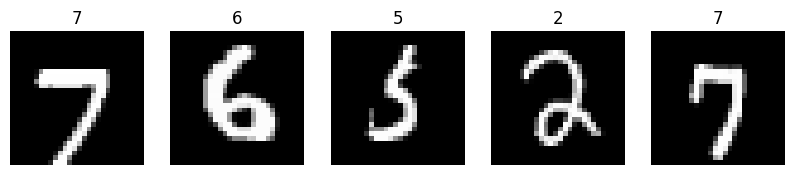

In [ ]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(train_loader))

# Show first 5 images in one row
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(labels[i].item())
    axes[i].axis('off')

plt.show()


Architecture

Input (28×28 = 784 pixels)
        ↓
Hidden Layer (128 neurons + ReLU)
        ↓
Output Layer (10 neurons → digits 0–9)


In [ ]:
# -----------------------------
# 2. Define simple neural network (MLP)
# -----------------------------
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)   # Flatten image
        x = self.relu(self.fc1(x))
        x = self.fc2(x)         # logits (no softmax here)
        return x

model = SimpleNN()

In [ ]:
# -----------------------------
# 3. Loss and optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# -----------------------------
# 4. Training loop
# -----------------------------
epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 324.9714
Epoch 2, Loss: 150.1213
Epoch 3, Loss: 102.7461
Epoch 4, Loss: 77.8182
Epoch 5, Loss: 61.0505


In [ ]:
# -----------------------------
# 5. Testing
# -----------------------------
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 97.58%
